# Czyszczenie danych

Celem etapu jest przygotowanie danych do analizy poprzez sprawdzenie braków danych, typów zmiennych oraz wartości odstających.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

sales = pd.read_csv("../Dane/Przetworzone/sales_all_months.csv")

Sprawdzamy liczbę brakujących wartości w każdej kolumnie. Pozwala to ocenić jakość danych i zdecydować, które zmienne wymagają: imputacji, usunięcia lub pozostawienia jako brakujące.

In [26]:
sales.isna().sum()

id                           0
city                         0
type                     42261
squareMeters                 0
rooms                        0
floor                    34594
floorCount                2383
buildYear                32216
latitude                     0
longitude                    0
centreDistance               0
poiCount                     0
schoolDistance             168
clinicDistance             728
postOfficeDistance         248
kindergartenDistance       207
restaurantDistance         479
collegeDistance           5436
pharmacyDistance           277
ownership                    0
buildingMaterial         77382
condition               146307
hasParkingSpace              0
hasBalcony                   0
hasElevator               9702
hasSecurity                  0
hasStorageRoom               0
price                        0
month                        0
dtype: int64

In [27]:
missing_summary = pd.DataFrame({
    "missing_count": sales.isna().sum(),
    "missing_percent": sales.isna().mean()*100
})

missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
condition,146307,74.811319
buildingMaterial,77382,39.567823
type,42261,21.609363
floor,34594,17.688988
buildYear,32216,16.473043
hasElevator,9702,4.960934
collegeDistance,5436,2.779596
floorCount,2383,1.218502
clinicDistance,728,0.372249
restaurantDistance,479,0.244928


Największe braki: condition, buildingMaterial, type, floor, buildYear, hasElevator, collegeDistance i floorCount. Teraz sprawdzamy jeszcze podstawowe informacje o zbiorze: liczba rekordów, typy danych oraz liczba niepustych wartości. To potwierdzi nam: które kolumny są liczbowe, które tekstowe i czy typy danych są poprawne.

In [28]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 195568 entries, 0 to 195567
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    195568 non-null  str    
 1   city                  195568 non-null  str    
 2   type                  153307 non-null  str    
 3   squareMeters          195568 non-null  float64
 4   rooms                 195568 non-null  float64
 5   floor                 160974 non-null  float64
 6   floorCount            193185 non-null  float64
 7   buildYear             163352 non-null  float64
 8   latitude              195568 non-null  float64
 9   longitude             195568 non-null  float64
 10  centreDistance        195568 non-null  float64
 11  poiCount              195568 non-null  float64
 12  schoolDistance        195400 non-null  float64
 13  clinicDistance        194840 non-null  float64
 14  postOfficeDistance    195320 non-null  float64
 15  kindergarte

Weryfikujemy liczbę mieszkań i zmiennych.

In [29]:
sales.shape

(195568, 29)

Obliczamy podstawowe statystyki dla zmiennych liczbowych.

In [30]:
sales.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,195568.000000,195568.000000,160974.000000,193185.000000,163352.000000,195568.000000,195568.000000,195568.000000,195568.000000,195400.000000,194840.000000,195320.000000,195361.000000,195089.000000,190132.00000,195291.000000,1.955680e+05
mean,58.697667,2.679222,3.332414,5.309113,1985.976346,52.026288,19.465989,4.351114,20.672037,0.412651,0.970287,0.516340,0.367560,0.345257,1.44327,0.358114,7.841833e+05
std,21.407206,0.915024,2.531684,3.312234,33.812810,1.335275,1.783264,2.835764,24.325708,0.464193,0.888884,0.498013,0.444673,0.463510,1.10457,0.457679,4.097092e+05
min,25.000000,1.000000,1.000000,1.000000,1850.000000,49.978999,14.447100,0.010000,0.000000,0.002000,0.001000,0.001000,0.001000,0.001000,0.00400,0.001000,1.500000e+05
25%,44.000000,2.000000,2.000000,3.000000,1967.000000,51.108796,18.523270,2.010000,7.000000,0.176000,0.356000,0.239000,0.156000,0.114000,0.57700,0.142000,5.200000e+05
50%,54.600000,3.000000,3.000000,4.000000,1994.000000,52.194596,19.899434,3.980000,14.000000,0.290000,0.676000,0.393000,0.262000,0.229000,1.12000,0.239000,6.990000e+05
75%,68.550000,3.000000,4.000000,6.000000,2016.000000,52.409006,20.989907,6.150000,24.000000,0.468000,1.237000,0.623000,0.416000,0.409000,2.05500,0.406000,9.300000e+05
max,150.000000,6.000000,29.000000,29.000000,2024.000000,54.606460,23.208873,16.940000,212.000000,4.946000,4.999000,4.970000,4.961000,4.985000,5.00000,4.992000,3.250000e+06


Nie widać nieścisłości. Ponieważ mamy dużo kolumn typu str sprawdzamy najczęściej występujące wartości w kolumnach tekstowych.

In [31]:
sales.describe(include="object")

C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_14056\2732439258.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sales.describe(include="object")


,id,city,type,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,month
count,195568,195568,153307,195568,118186,49261,195568,195568,185866,195568,195568,195568
unique,92967,15,3,3,2,2,2,2,2,2,2,11
top,d59165364f1c4b3d658890e808e7d77c,warszawa,blockOfFlats,condominium,brick,premium,no,yes,no,no,no,2024_06
freq,11,59246,91368,176123,91899,27869,142410,112049,93662,173630,110583,21501


Sprawdzamy czy braki są losowe czy tworzą się wozry.

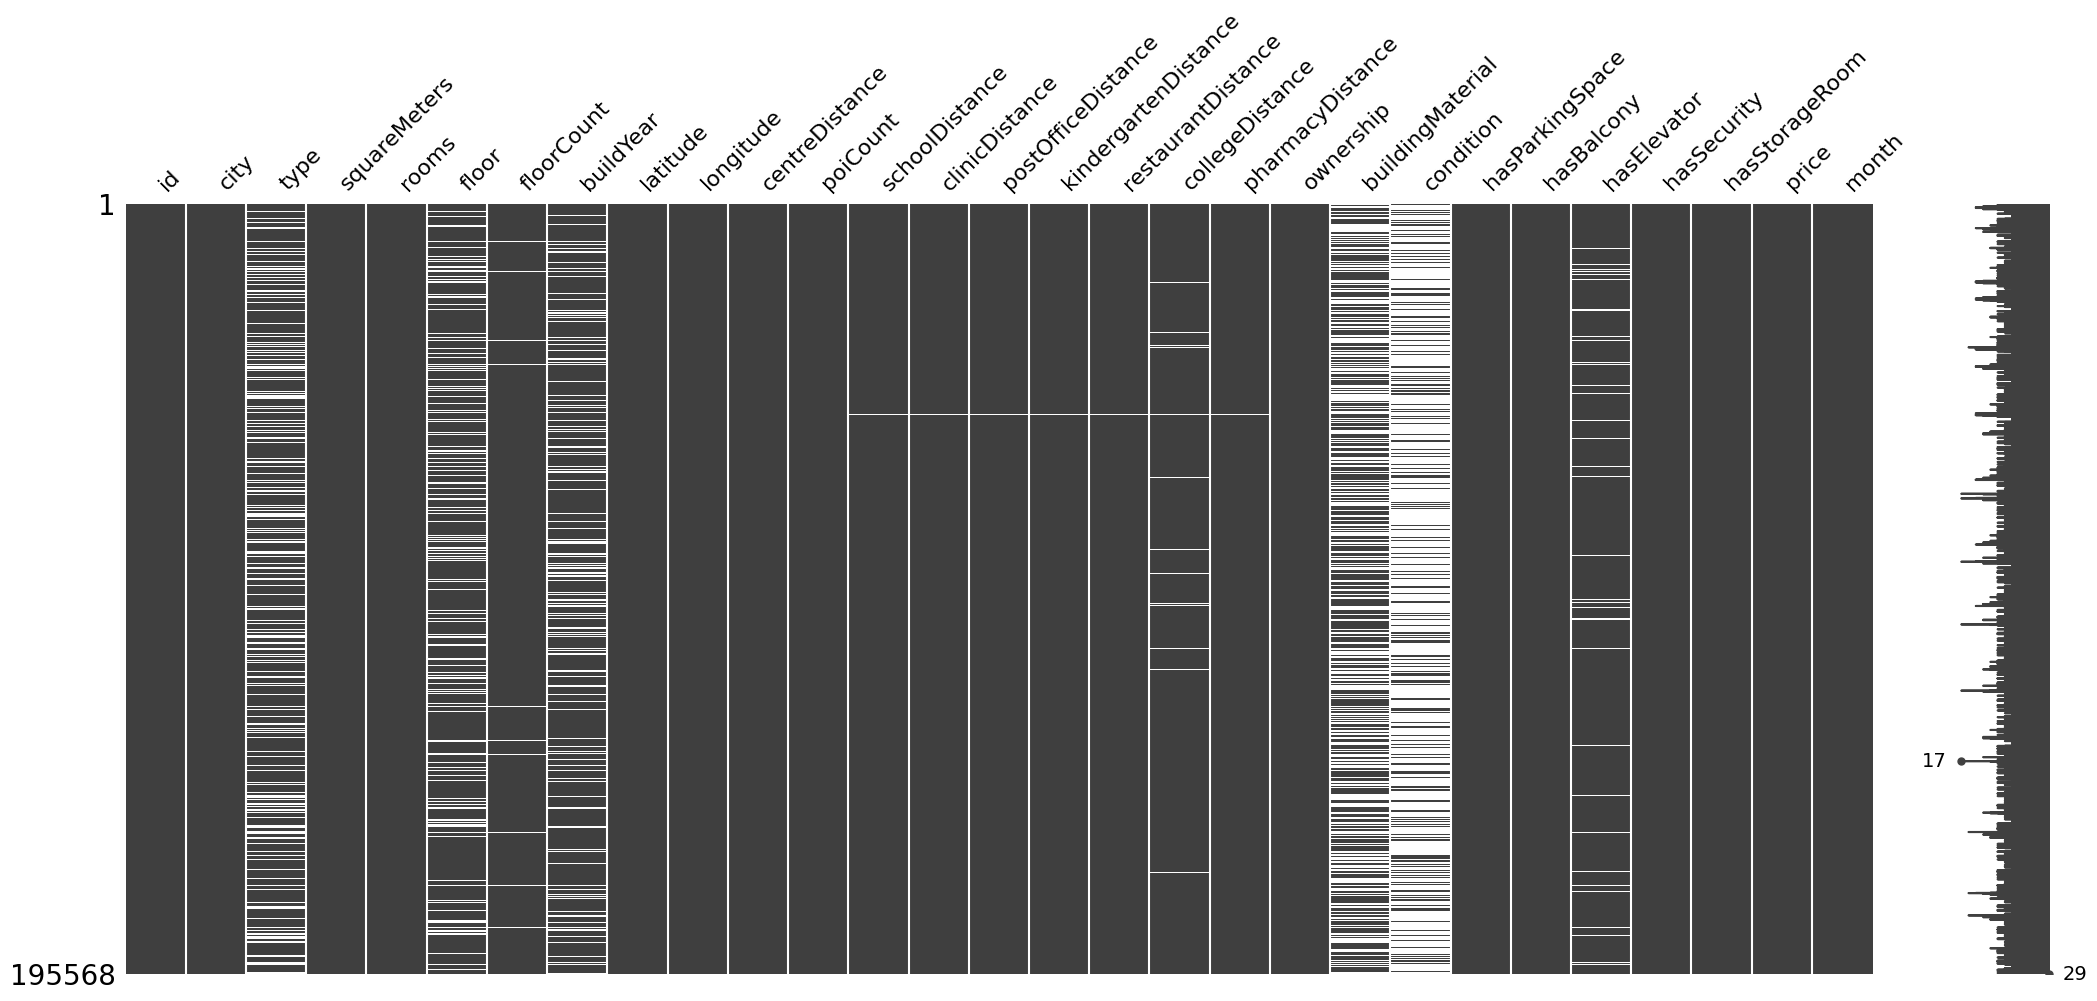

In [32]:
msno.matrix(sales)
plt.show()

Część braków występuje w konkretnych kolumnach.

Sprawdzamy korelację braków

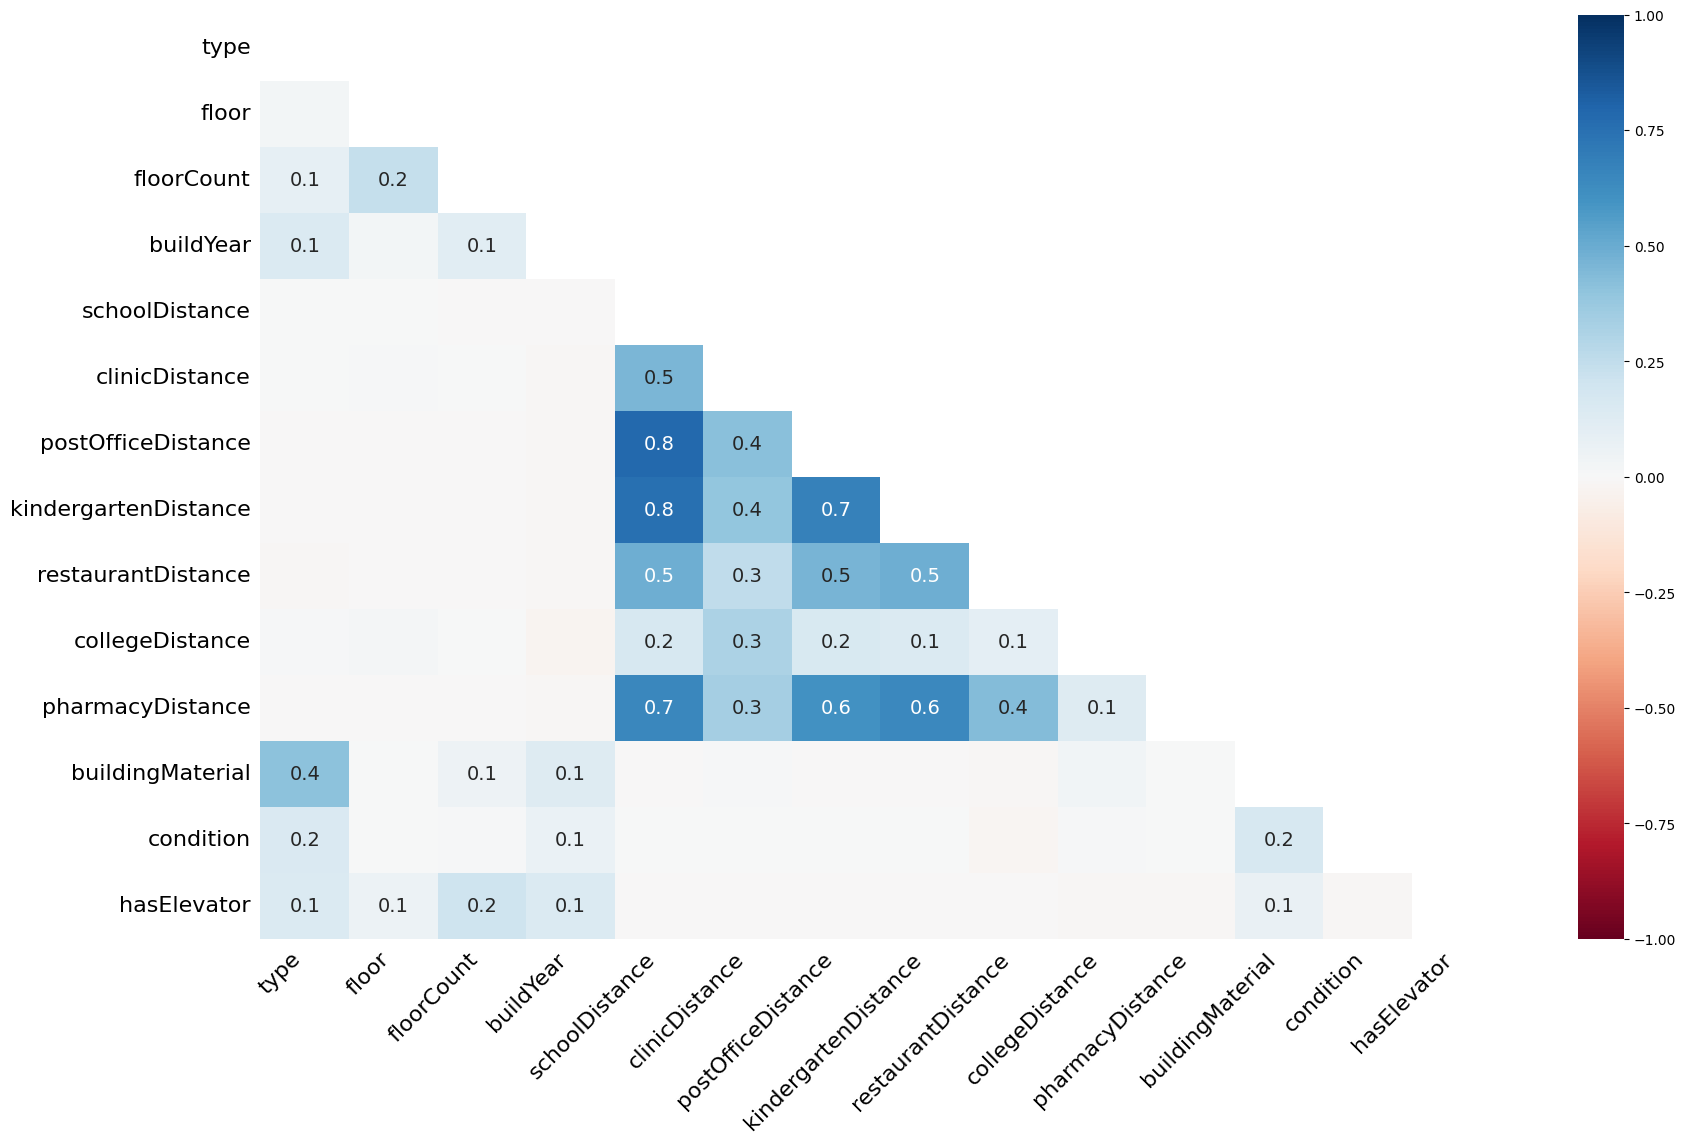

In [33]:
msno.heatmap(sales)
plt.show()

**Condition** - sporo braków - to raczej nie jest przykładowy brak techniczny. Stan mieszkania może być informacją, którą sprzedający może nie podawać. Możemy mieć do czynienia z MNAR (Missing Not At Random): mieszkanie w dobrym stanie - właściciel wpisuje, mieszkanie wymagające remontu - właściciel pomija fakt. Ta zmienna nie nadaje się do imputacji.

**BuildingMaterial** - prawdopodobnie zależy od typu nieruchomości. Sprawdzamy procent braków w obrębie typu nieruchomości. Szukamy odpowiedzi na pytanie "Dla każdego typu mieszkania: jaki procent rekordów ma podany materiał budynku, a jaki procent ma brak?".

In [34]:
pd.crosstab(
    sales["type"],
    sales["buildingMaterial"].isna(),
    normalize="index"
)

buildingMaterial,False,True
type,,
apartmentBuilding,1.000000,0.000000
blockOfFlats,0.512751,0.487249
tenement,1.000000,0.000000


Wszystkie rekordy apartmentBuilding i tenement nie mają braków. Wszystkie braki danych tej zmiennej pochodzą z blockOfFlats (48,7% mieszkań). Brak jest zależny od innej zmiennej (type) - mechanizm MAR (Missing at Random).

**Type** - wydaje się losowy. Tutaj możemy prawdopodobnie imputować modą albo stworzyć kategorię Unknwown.

**Floor i FloorCount** - czy braki korelują ze sobą? Jeśli braki w floor pokrywają się z brakami w floorCount, to może to być MAR (wspólna przyczyna). Jeśli są rozproszone niezależnie, to MCAR (losowe).

In [45]:
pd.crosstab(
    sales["floor"].isna(),
    sales["floorCount"].isna(),
    margins=True
)

floorCount,False,True,All
floor,,,
False,160974,0,160974
True,32211,2383,34594
All,193185,2383,195568


Nigdy nie ma sytuacji, że floor jest, a floorCount brakuje. 32211 rekordów - gdy floor brakuje, ale floorCount jest (prawie 94% z brakami floor). 2383 rekordy - gdy oba brakują (prawie 7% z brakami floor). To jest MAR (Missing At Random). Braki nie są losowe - są powiązane. Gdy brakuje floor, zwykle floorCount jest dostępny (może być wspólna przyczyna). W ramach czyszczenia danych, tam gdzie floor brakuje ale floorCount jest - można imputować floor z floorCount lub średnią wg typu. Gdzie oba brakują (2383) - usunąć lub imputować ostrożniej.

**BuildYear** - czy braki są zależne od typu nieruchomości?

In [47]:
pd.crosstab(
    sales["type"],
    sales["buildYear"].isna(),
    normalize="index"
)

buildYear,False,True
type,,
apartmentBuilding,0.932076,0.067924
blockOfFlats,0.859502,0.140498
tenement,0.803207,0.196793


Kamienice (tenement) mają ~20% braków - to najstarsza zabudowa, może nie mieć dokumentacji roku budowy.
Bloki mieszkalne mają 14% braków - pośrednio. Budynki apartamentowe mają najmniej braków (7%) - to nowsze/lepiej udokumentowane. To nie jest losowe - to MAR. Braki zależą od typu nieruchomości. Można imputować buildYear medianą lub trybem wg typu (bo MAR i imputacja wg grupy jest uzasadniona).

Do sprawdzenia pozostałe braki i ich zależności:
- hasElevator	9702	4.960934
- collegeDistance	5436	2.779596
- floorCount	2383	1.218502
- clinicDistance	728	0.372249
- restaurantDistance	479	0.244928
- pharmacyDistance	277	0.141639
- postOfficeDistance	248	0.126810
- kindergartenDistance	207	0.105846
- schoolDistance	168	0.085904